In [2]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/dsml_pandas/titanic (1).csv")

In [6]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Using** **IQR**

**Interquatite Range**

<Axes: >

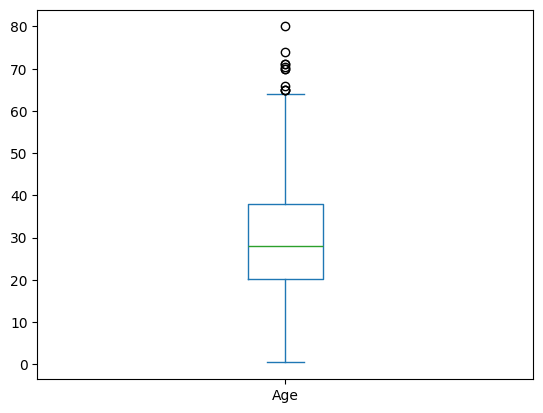

In [7]:
df.Age.plot.box()

In [8]:
Q1 = df.Age.quantile(q=0.25)
Q3 = df.Age.quantile(q=0.75)

In [9]:
IQR = Q3 - Q1

In [10]:
upper_limit = Q3 + 1.5 * IQR
lower_limit = Q3 - 1.5 * IQR

In [11]:
upper_limit, lower_limit

(np.float64(64.8125), np.float64(11.1875))

In [24]:
df_no_outliers = df[(df["Age"] <= upper_limit) & (df["Age"] >= lower_limit)]

<Axes: >

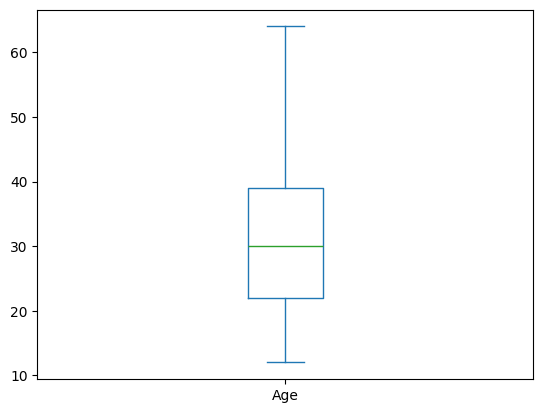

In [26]:
df_no_outliers.Age.plot.box()

In [15]:
outliers_free = df[(df["Age"] < upper_limit) | (df["Age"] > lower_limit)]

In [16]:
outliers_free

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
# Using Z-score

Z=X − μ​/σ


Research hypothesis testing

In [ ]:
import numpy as np
sample = [150, 155, 160, 165, 170, 180]
sample_mean = np.mean(sample)
sample_std = np.std(sample, ddof = 1) # delta degree of freedom
Z_score = (sample - sample_mean)/sample_std
Z_score

array([-1.2344268 , -0.77151675, -0.3086067 ,  0.15430335,  0.6172134 ,
        1.5430335 ])

In [ ]:
Z_score = abs(df.Age - df.Age.mean())/df.Age.std()

In [ ]:
Z_score

,Age
0,0.828128
1,0.539855
2,0.486132
3,0.283358
4,0.283358
...,...
885,0.625354
886,0.400633
887,1.084625
889,0.486132


In [ ]:
df[Z_score > 2.5]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
170,171,0,1,"Van der hoef, Mr. Wyckoff",male,61.0,0,0,111240,33.5000,B19,S
252,253,0,1,"Stead, Mr. William Thomas",male,62.0,0,0,113514,26.5500,C87,S
275,276,1,1,"Andrews, Miss. Kornelia Theodosia",female,63.0,1,0,13502,77.9583,D7,S
326,327,0,3,"Nysveen, Mr. Johan Hansen",male,61.0,0,0,345364,6.2375,NaN,S
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,C23 C25 C27,S
483,484,1,3,"Turkula, Mrs. (Hedwig)",female,63.0,0,0,4134,9.5875,NaN,S
545,546,0,1,"Nicholson, Mr. Arthur Ernest",male,64.0,0,0,693,26.0000,NaN,S
555,556,0,1,"Wright, Mr. George",male,62.0,0,0,113807,26.5500,NaN,S
570,571,1,2,"Harris, Mr. George",male,62.0,0,0,S.W./PP 752,10.5000,NaN,S
625,626,0,1,"Sutton, Mr. Frederick",male,61.0,0,0,36963,32.3208,D50,S


In [ ]:
# using z_score we can remove outliers